In [67]:
import sklearn
from sklearn.datasets import fetch_california_housing

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Phase 1

1 Load the dataset and convert it into a pandas DataFrame

In [68]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data)
target = pd.DataFrame(housing.target)
col_names = pd.DataFrame(housing.feature_names)

# briefly view the dataframes
display(data.head())
display(target.head())
display(col_names)

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


,0
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


,0
0,MedInc
1,HouseAge
2,AveRooms
3,AveBedrms
4,Population
5,AveOccup
6,Latitude
7,Longitude


In [69]:
print(type(col_names))

<class 'pandas.DataFrame'>


In [70]:
print(f"shape of the housing dataset: {housing.data.shape}")
print(f"shape of target: {housing.target.shape}")

shape of the housing dataset: (20640, 8)
shape of target: (20640,)


In [71]:
data.columns = col_names[0].tolist()
data.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='str')

In [72]:
data = pd.concat([data,target],axis=1)
data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,0
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [73]:
data = data.rename(columns={data.columns[-1]:"MedHouseVal"})
data.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [74]:
print(f"dataset shape: {data.shape}")
print(f"data types: {data.dtypes}")


dataset shape: (20640, 9)
data types: MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [75]:
print(f"missing values: {data.isna().sum()}")

missing values: MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [76]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [77]:
print(f"sort values by income: {data.sort_values(by=["MedInc"])}")
print(f"sort values by house age: {data.sort_values(by=["HouseAge"])}")
print(f"sort values by house value: {data.sort_values(by=["MedHouseVal"])}")

sort values by income:         MedInc  HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
4861    0.4999      29.0   2.373272   1.055300      2690.0  12.396313   
7125    0.4999      36.0   2.500000   0.833333        15.0   2.500000   
6688    0.4999      28.0   7.677419   1.870968       142.0   4.580645   
19800   0.4999      15.0  11.596491   2.561404       131.0   2.298246   
6343    0.4999      52.0   3.875000   0.562500        44.0   2.750000   
...        ...       ...        ...        ...         ...        ...   
4605   15.0001      52.0   8.483019   0.962264       813.0   3.067925   
4606   15.0001      52.0   9.204969   1.062112       531.0   3.298137   
4626   15.0001      52.0   7.958333   0.833333       457.0   3.808333   
8848   15.0001      52.0   8.907583   1.099526      1407.0   3.334123   
17166  15.0001      32.0   8.116608   1.014134       814.0   2.876325   

       Latitude  Longitude  MedHouseVal  
4861      34.02    -118.28      5.00001  
7125      33.90 

In [78]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Phase 3: Visualisation

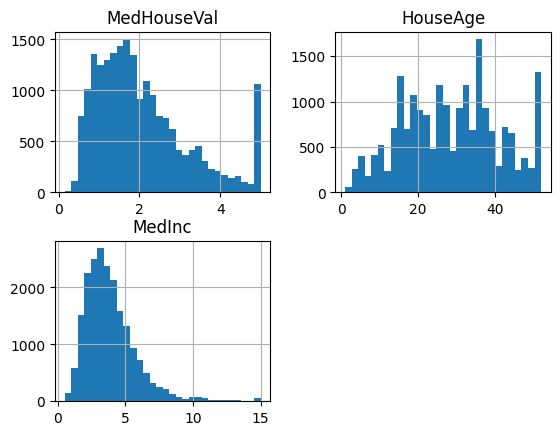

In [84]:
data[["MedHouseVal", "HouseAge", "MedInc"]].hist(bins=30)
plt.show()

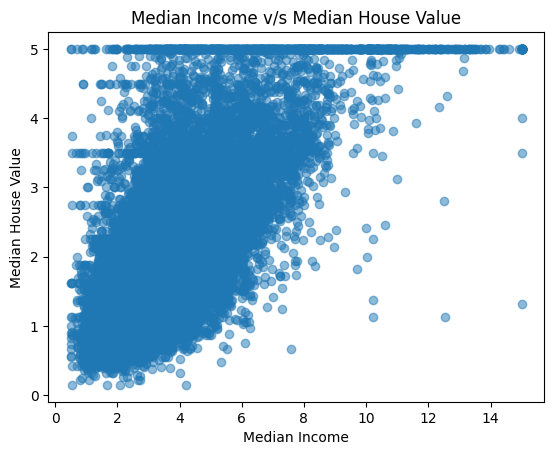

In [87]:
plt.scatter(
    x=data["MedInc"],
    y=data["MedHouseVal"],
    alpha=0.5,
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income v/s Median House Value")
plt.show()

some interpretations:
1. as the median income increases, the median house value also increases - positive correlation. 
2. the 